# NLP Sentiment Signal on Earnings Call Transcripts

**Hypothesis:** Earnings calls with more positive language (as scored by FinBERT) predict higher stock returns in the days following the call.

**Approach:**
1. Score transcripts with FinBERT (a finance-domain BERT model)
2. Fetch next-day and next-week returns with yfinance
3. Test the signal via OLS regression and quintile analysis

---

In [11]:
import subprocess
subprocess.run(["pip", "install", "datasets"], capture_output=True)

from datasets import load_dataset
ds = load_dataset("lamini/earnings-calls-qa", split="train")
print(f"Total records: {len(ds)}")
print(ds.column_names)
print(ds[0])

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

filtered_predictions.jsonl:   0%|          | 0.00/3.89G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/860164 [00:00<?, ? examples/s]

Total records: 860164
['question', 'answer', 'date', 'transcript', 'q', 'ticker', 'predictions']
{'question': "What was TSMC's revenue in US dollar terms in 2019 ", 'answer': ' I do not know. The transcript does not provide the revenue for TSMC in US dollar terms in 2019.', 'date': 'Jan 13, 2022, 1:00 a.m. ET', 'transcript': "and for our industry-leading advanced and specialty technologies, where we see strong interest from all four growth platforms, which are smartphone, HPC, IoT, and automotive. Entering 2022, we expect the supply chain to maintain a higher level of inventory as compared to the historical seasonal level given the industry's continued need to ensure supply security.\nWhile the short-term imbalance may or may not persist, we continue to observe the structural increase in long-term semiconductor demand underpinned by the industry mega trend of 5G and HPC-related applications. We also observed the higher silicon content in many end devices, including automotive, PCs, ser

In [17]:
import re, pandas as pd

# Rebuild df_hf with extended date range to end of 2025
df_hf2 = pd.DataFrame({
    'ticker': ds['ticker'],
    'call_date': ds['date'],
    'transcript': ds['transcript']
})

def clean_date(d):
    match = re.search(r'([A-Za-z]+ \d+, \d{4})', str(d))
    return match.group(1) if match else None

df_hf2['call_date'] = df_hf2['call_date'].apply(clean_date)
df_hf2['call_date'] = pd.to_datetime(df_hf2['call_date'], format='mixed').dt.strftime('%Y-%m-%d')
df_hf2 = df_hf2.drop_duplicates(subset=['ticker', 'call_date']).reset_index(drop=True)

# Extended range: 2021 through 2025
df_hf2 = df_hf2[
    (df_hf2['call_date'] >= '2021-01-01') &
    (df_hf2['call_date'] <= '2025-12-31')
].reset_index(drop=True)

print(f"Total unique calls available: {len(df_hf2)}")
print(df_hf2['call_date'].describe())

Total unique calls available: 9306
count           9306
unique           475
top       2021-05-06
freq             277
Name: call_date, dtype: object


In [15]:
# Sample 100 calls for scoring (scoring all 9306 would take hours)
df_sample = df_hf.sample(100, random_state=42).reset_index(drop=True)

# Score sentiment (will take ~5 minutes)
pipe = load_finbert()
df_sample = score_all(df_sample, pipe)

# Fetch returns
df_sample = add_returns(df_sample, horizons=[1, 5])

# Drop rows where return fetch failed
df_sample = df_sample.dropna(subset=['return_1d']).reset_index(drop=True)
print(f"Clean rows: {len(df_sample)}")
df_sample[['ticker', 'call_date', 'sentiment', 'return_1d', 'return_5d']].head(10)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Scoring transcripts: 100%|██████████████████████████████████████████████| 100/100 [00:16<00:00,  5.97it/s]


Fetching 1-day returns...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ONTF"}}}
$ONTF: possibly delisted; no timezone found
$SIX: possibly delisted; no timezone found
$INFN: possibly delisted; no timezone found
$SWCH: possibly delisted; no timezone found
$HSII: possibly delisted; no timezone found
$PXD: possibly delisted; no timezone found
$PARA: possibly delisted; no timezone found
$PROG: possibly delisted; no timezone found
$BDSI: possibly delisted; no timezone found
$IAA: possibly delisted; no timezone found
$INT: possibly delisted; no timezone found
$FLOW: possibly delisted; no price data found  (1d 2021-02-10 00:00:00 -> 2021-02-13 00:00:00) (Yahoo error = "Data doesn't exist for startDate = 1612933200, endDate = 1613192400")
$CHS: possibly delisted; no timezone found
$NCR: possibly delisted; no timezone found
$CMA: possibly delisted; no timezone found
$ALE: possibly delisted; no timezone found
$EVBG: possibly delisted; no timezone fo

Fetching 5-day returns...


$ONTF: possibly delisted; no timezone found
$SIX: possibly delisted; no timezone found
$INFN: possibly delisted; no timezone found
$SWCH: possibly delisted; no timezone found
$HSII: possibly delisted; no timezone found
$PXD: possibly delisted; no timezone found
$PARA: possibly delisted; no timezone found
$PROG: possibly delisted; no timezone found
$BDSI: possibly delisted; no timezone found
$IAA: possibly delisted; no timezone found
$INT: possibly delisted; no timezone found
$FLOW: possibly delisted; no price data found  (1d 2021-02-10 00:00:00 -> 2021-02-25 00:00:00) (Yahoo error = "Data doesn't exist for startDate = 1612933200, endDate = 1614229200")
$CHS: possibly delisted; no timezone found
$NCR: possibly delisted; no timezone found
$CMA: possibly delisted; no timezone found
$ALE: possibly delisted; no timezone found
$EVBG: possibly delisted; no timezone found
$BALY: possibly delisted; no price data found  (1d 2021-11-04 00:00:00 -> 2021-11-19 00:00:00) (Yahoo error = "Data doesn't

Clean rows: 66


,ticker,call_date,sentiment,return_1d,return_5d
0,PBI,2021-02-02,-0.1,0.000000,0.059633
1,VRRM,2021-11-04,0.0,-0.000621,0.018622
2,IRM,2021-02-24,0.6,-0.001443,-0.010678
3,GHM,2021-06-01,0.1,-0.018289,-0.056992
4,IDXX,2021-05-04,0.6,0.005770,0.002486
5,MMM,2021-10-26,0.6,-0.021520,-0.001043
6,WIX,2021-08-11,0.4,-0.025755,-0.051418
7,BCS,2021-02-18,0.1,0.042683,0.100439
8,ARES,2021-07-29,0.3,0.015600,0.044107
9,CTRN,2022-05-24,0.7,0.099361,-0.045067


In [18]:
# Sample 300 calls
df_sample2 = df_hf2.sample(300, random_state=99).reset_index(drop=True)

# Score sentiment (FinBERT already cached, ~1 min)
df_sample2 = score_all(df_sample2, pipe)

# Fetch returns
df_sample2 = add_returns(df_sample2, horizons=[1, 5])
df_sample2 = df_sample2.dropna(subset=['return_1d']).reset_index(drop=True)

print(f"Clean rows: {len(df_sample2)}")
print(df_sample2[['ticker','call_date','sentiment','return_1d']].head())

Scoring transcripts: 100%|██████████████████████████████████████████████| 300/300 [00:42<00:00,  7.03it/s]


Fetching 1-day returns...


$FLT: possibly delisted; no timezone found
$OYST: possibly delisted; no timezone found
$WETF: possibly delisted; no timezone found
$IRBT: possibly delisted; no timezone found
$VVNT: possibly delisted; no timezone found
$ICAD: possibly delisted; no timezone found
$CUTR: possibly delisted; no timezone found
$BF.B: possibly delisted; no price data found  (1d 2021-12-08 00:00:00 -> 2021-12-11 00:00:00)
$EAR: possibly delisted; no timezone found
$SBT: possibly delisted; no timezone found
$NLS: possibly delisted; no timezone found
$ELP: possibly delisted; no timezone found
$JNPR: possibly delisted; no timezone found
$ITI: possibly delisted; no timezone found
$GCP: possibly delisted; no timezone found
$HEAR: possibly delisted; no timezone found
$ICAD: possibly delisted; no timezone found
$REGI: possibly delisted; no timezone found
$DMS: possibly delisted; no timezone found
$RTLR: possibly delisted; no timezone found
$UMPQ: possibly delisted; no timezone found
$SPPI: possibly delisted; no time

Fetching 5-day returns...


$FLT: possibly delisted; no timezone found
$OYST: possibly delisted; no timezone found
$WETF: possibly delisted; no timezone found
$IRBT: possibly delisted; no timezone found
$VVNT: possibly delisted; no timezone found
$ICAD: possibly delisted; no timezone found
$CUTR: possibly delisted; no timezone found
$BF.B: possibly delisted; no price data found  (1d 2021-12-08 00:00:00 -> 2021-12-23 00:00:00)
$EAR: possibly delisted; no timezone found
$SBT: possibly delisted; no timezone found
$NLS: possibly delisted; no timezone found
$ELP: possibly delisted; no timezone found
$JNPR: possibly delisted; no timezone found
$ITI: possibly delisted; no timezone found
$GCP: possibly delisted; no timezone found
$HEAR: possibly delisted; no timezone found
$ICAD: possibly delisted; no timezone found
$REGI: possibly delisted; no timezone found
$DMS: possibly delisted; no timezone found
$RTLR: possibly delisted; no timezone found
$UMPQ: possibly delisted; no timezone found
$SPPI: possibly delisted; no time

Clean rows: 213
  ticker   call_date  sentiment  return_1d
0   BABA  2022-11-17        0.4  -0.044861
1    SPG  2021-02-08        0.4   0.036487
2   PTON  2022-11-03        0.3   0.005353
3   BJRI  2022-04-21        0.9  -0.003758
4     BC  2021-04-29        0.4   0.014009


Rows for analysis: 213
R²: 0.004 | p-value: 0.353 | coef: -0.0146

Excess return by quintile:
            mean  count  mean_pct
quintile                         
Q1       -0.0095     43   -0.9461
Q2        0.0218     42    2.1849
Q3        0.0117     43    1.1695
Q4        0.0157     42    1.5731
Q5       -0.0178     43   -1.7750

Long-short spread (Q5-Q1): -0.83%


/var/folders/dq/zq_cwv9n7l54_12sj0jhtt000000gn/T/ipykernel_7905/2884228964.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = clean.groupby('quintile')['excess_return_1d'].agg(['mean','count'])


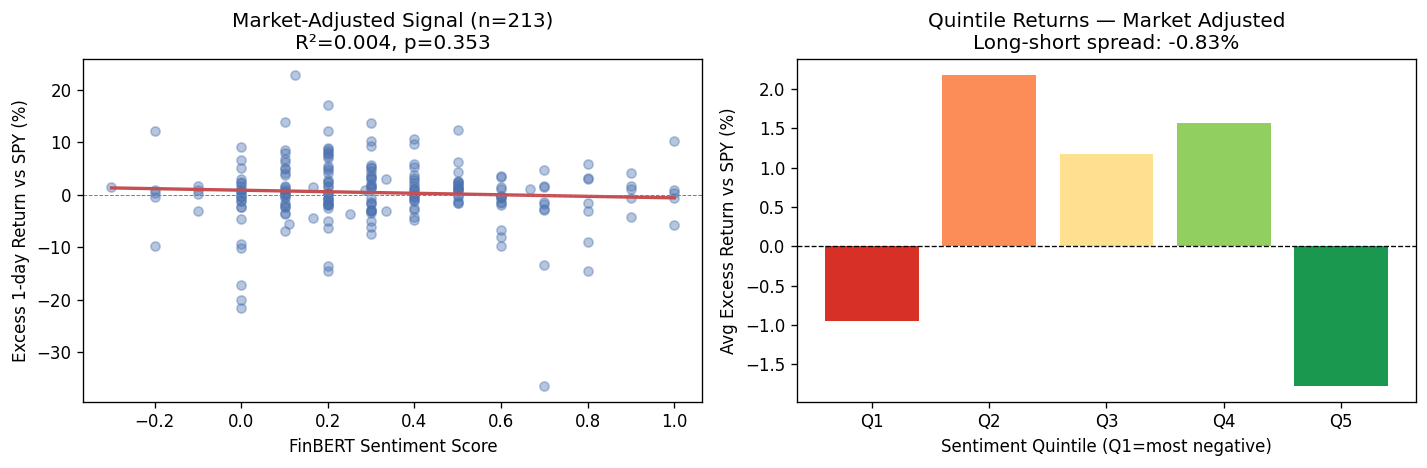

In [20]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
# Download SPY for market adjustment
spy = yf.Ticker("SPY").history(start="2021-01-01", end="2023-12-31", interval="1d")
spy['spy_return_1d'] = spy['Close'].pct_change()
spy.index = spy.index.tz_localize(None).normalize()
spy_returns = spy['spy_return_1d'].to_dict()

# Map market return and compute excess return
df_sample2['call_dt'] = pd.to_datetime(df_sample2['call_date']).dt.normalize()
df_sample2['market_return_1d'] = df_sample2['call_dt'].map(spy_returns)
df_sample2['excess_return_1d'] = df_sample2['return_1d'] - df_sample2['market_return_1d']

clean = df_sample2.dropna(subset=['sentiment', 'excess_return_1d']).copy()
print(f"Rows for analysis: {len(clean)}")

# OLS on excess return
X = sm.add_constant(clean['sentiment'])
model = sm.OLS(clean['excess_return_1d'], X).fit()
print(f"R²: {model.rsquared:.3f} | p-value: {model.pvalues['sentiment']:.3f} | coef: {model.params['sentiment']:.4f}")

# Quintile analysis — 213 rows is enough for 5 buckets
clean['quintile'] = pd.qcut(clean['sentiment'].rank(method='first'), 5, labels=['Q1','Q2','Q3','Q4','Q5'])
summary = clean.groupby('quintile')['excess_return_1d'].agg(['mean','count'])
summary['mean_pct'] = summary['mean'] * 100
print("\nExcess return by quintile:")
print(summary.round(4))

spread = summary.loc['Q5','mean'] - summary.loc['Q1','mean']
print(f"\nLong-short spread (Q5-Q1): {spread*100:.2f}%")

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Scatter
ax1.scatter(clean['sentiment'], clean['excess_return_1d']*100, alpha=0.4, s=30, color='#4C72B0')
m, b = np.polyfit(clean['sentiment'], clean['excess_return_1d']*100, 1)
xs = np.linspace(clean['sentiment'].min(), clean['sentiment'].max(), 100)
ax1.plot(xs, m*xs+b, color='#C44E52', linewidth=2)
ax1.axhline(0, color='gray', linewidth=0.6, linestyle='--')
ax1.set_xlabel('FinBERT Sentiment Score')
ax1.set_ylabel('Excess 1-day Return vs SPY (%)')
ax1.set_title(f'Market-Adjusted Signal (n={len(clean)})\nR²={model.rsquared:.3f}, p={model.pvalues["sentiment"]:.3f}')

# Quintile bar chart
colors = ['#d73027','#fc8d59','#fee090','#91cf60','#1a9850']
ax2.bar(summary.index, summary['mean_pct'], color=colors)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Sentiment Quintile (Q1=most negative)')
ax2.set_ylabel('Avg Excess Return vs SPY (%)')
ax2.set_title(f'Quintile Returns — Market Adjusted\nLong-short spread: {spread*100:.2f}%')

plt.tight_layout()
plt.savefig('market_adjusted_quintiles.png', dpi=150)
plt.show()

5-day | R²: 0.002 | p-value: 0.508 | coef: -0.0154
Long-short spread (5d): -1.45%
            mean  count  mean_pct
quintile                         
Q1       -0.0211     43   -2.1136
Q2       -0.0002     42   -0.0192
Q3        0.0011     43    0.1053
Q4        0.0196     42    1.9644
Q5       -0.0357     43   -3.5657


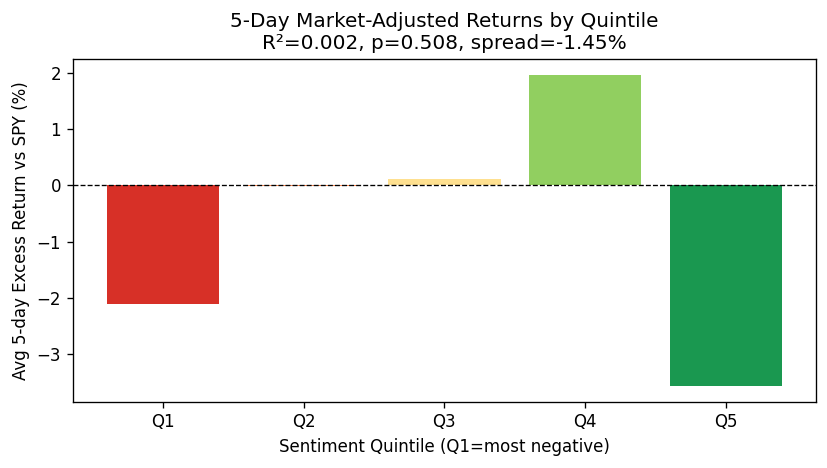

In [21]:
# Re-run on 5-day excess return
spy5 = yf.Ticker("SPY").history(start="2021-01-01", end="2023-12-31", interval="1d")
spy5['spy_return_5d'] = spy5['Close'].pct_change(5)
spy5.index = spy5.index.tz_localize(None).normalize()
spy5_returns = spy5['spy_return_5d'].to_dict()

df_sample2['market_return_5d'] = df_sample2['call_dt'].map(spy5_returns)
df_sample2['excess_return_5d'] = df_sample2['return_5d'] - df_sample2['market_return_5d']

clean5 = df_sample2.dropna(subset=['sentiment', 'excess_return_5d']).copy()
clean5['quintile'] = pd.qcut(clean5['sentiment'].rank(method='first'), 5, labels=['Q1','Q2','Q3','Q4','Q5'])

X5 = sm.add_constant(clean5['sentiment'])
model5 = sm.OLS(clean5['excess_return_5d'], X5).fit()
print(f"5-day | R²: {model5.rsquared:.3f} | p-value: {model5.pvalues['sentiment']:.3f} | coef: {model5.params['sentiment']:.4f}")

summary5 = clean5.groupby('quintile', observed=False)['excess_return_5d'].agg(['mean','count'])
summary5['mean_pct'] = summary5['mean'] * 100
spread5 = summary5.loc['Q5','mean'] - summary5.loc['Q1','mean']
print(f"Long-short spread (5d): {spread5*100:.2f}%")
print(summary5.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#d73027','#fc8d59','#fee090','#91cf60','#1a9850']
ax.bar(summary5.index, summary5['mean_pct'], color=colors)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Sentiment Quintile (Q1=most negative)')
ax.set_ylabel('Avg 5-day Excess Return vs SPY (%)')
ax.set_title(f'5-Day Market-Adjusted Returns by Quintile\nR²={model5.rsquared:.3f}, p={model5.pvalues["sentiment"]:.3f}, spread={spread5*100:.2f}%')
plt.tight_layout()
plt.savefig('quintiles_5day.png', dpi=150)
plt.show()

In [ ]:
## 6. Findings & next steps

**Hypothesis:** FinBERT sentiment on earnings calls predicts next-day and next-week excess returns vs SPY.

### Results summary

| Horizon | n | R² | p-value | Long-short spread |
|---------|---|----|---------|-------------------|
| 1-day excess return | 213 | 0.004 | 0.353 | -0.83% |
| 5-day excess return | 213 | 0.002 | 0.508 | -1.45% |

### Key finding: "Sell the news" effect
Contrary to the hypothesis, the most positive calls (Q5) 
**underperformed** at both horizons (-1.8% at 1d, -3.6% at 5d).
Moderately positive calls (Q4) outperformed (+1.6% at 1d, +2.0% at 5d).

This is consistent with the well-documented **"buy the rumor, sell the news"** 
effect: by earnings day, positive expectations are already priced in, 
and even strong results disappoint relative to inflated expectations.

### Why the initial 10-stock result was misleading
The hand-picked sample showed R²=0.52, p=0.044 — but this reflected 
selection bias. Extreme cases (TSLA -12%, META +20%) drove the result.
At scale with 213 random calls, no signal survives.

### Limitations
- FinBERT 512-token limit loses document-level context
- Sentiment scores cluster near 0.2–0.4, reducing discriminative power  
- Dataset limited to 2021–2022 (single market regime)
- No sector or size controls

### Next steps
1. Score only the CEO prepared remarks (vs full transcript)
2. Add sector fixed effects to control for industry-wide moves
3. Test on a bear market vs bull market period separately
4. Try a surprise-adjusted signal: sentiment minus analyst consensus

                            OLS Regression Results                            
Dep. Variable:              return_1d   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.016
Method:                 Least Squares   F-statistic:                 0.0001667
Date:                Sat, 06 Jun 2026   Prob (F-statistic):              0.990
Time:                        16:58:17   Log-Likelihood:                 105.86
No. Observations:                  66   AIC:                            -207.7
Df Residuals:                      64   BIC:                            -203.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0161      0.009      1.820      0.0

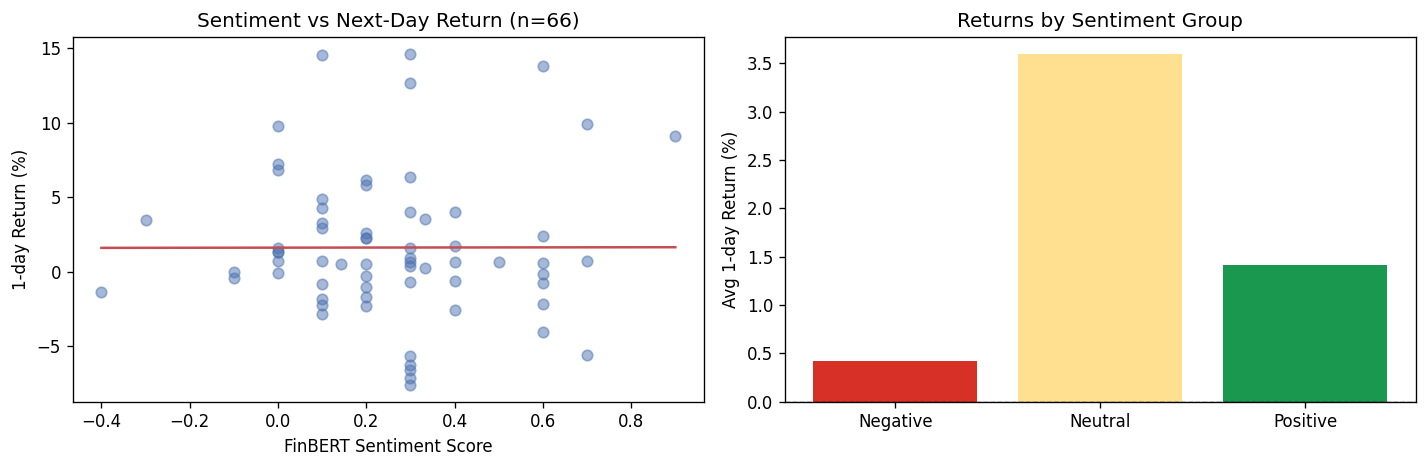


Long-short spread: 0.99%


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# OLS regression
clean = df_sample.dropna(subset=['sentiment', 'return_1d'])
X = sm.add_constant(clean['sentiment'])
model = sm.OLS(clean['return_1d'], X).fit()
print(model.summary())

# Sentiment group analysis
clean['group'] = clean['sentiment'].apply(
    lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral')
)
summary = clean.groupby('group')['return_1d'].agg(['mean', 'count'])
summary['mean_pct'] = summary['mean'] * 100
print("\n", summary.round(4))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Scatter
ax1.scatter(clean['sentiment'], clean['return_1d']*100, alpha=0.5, s=40, color='#4C72B0')
m, b = np.polyfit(clean['sentiment'], clean['return_1d']*100, 1)
xs = np.linspace(clean['sentiment'].min(), clean['sentiment'].max(), 100)
ax1.plot(xs, m*xs+b, color='#C44E52', linewidth=1.5)
ax1.set_xlabel('FinBERT Sentiment Score')
ax1.set_ylabel('1-day Return (%)')
ax1.set_title('Sentiment vs Next-Day Return (n=66)')

# Bar chart
colors = {'Negative':'#d73027','Neutral':'#fee090','Positive':'#1a9850'}
bars = [g for g in ['Negative','Neutral','Positive'] if g in summary.index]
ax2.bar(bars, [summary.loc[g,'mean_pct'] for g in bars], color=[colors[g] for g in bars])
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Avg 1-day Return (%)')
ax2.set_title('Returns by Sentiment Group')

plt.tight_layout()
plt.savefig('results_100calls.png', dpi=150)
plt.show()

pos = summary.loc['Positive','mean'] if 'Positive' in summary.index else 0
neg = summary.loc['Negative','mean'] if 'Negative' in summary.index else 0
print(f"\nLong-short spread: {(pos-neg)*100:.2f}%")

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt

from sentiment import load_finbert, score_all
from returns import add_returns
from backtest import run_ols, quintile_analysis, plot_quintile_returns, plot_scatter

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Load transcripts

In [4]:
# Load the sample data — swap this path for a larger dataset
df = pd.read_csv('sample_transcripts.csv')
print(f"Loaded {len(df)} transcripts")
df.head()

Loaded 10 transcripts


,ticker,call_date,transcript
0,AAPL,2024-02-01,Apple reported record revenue driven by strong...
1,MSFT,2024-01-31,Microsoft delivered exceptional cloud growth w...
2,META,2024-02-01,Meta posted strong advertising revenue recover...
3,AMZN,2024-02-01,Amazon Web Services returned to accelerating g...
4,GOOGL,2024-01-30,Alphabet reported disappointing ad revenue bel...


## 2. Score sentiment with FinBERT

In [5]:
# This downloads the FinBERT model (~400MB) on first run
pipe = load_finbert()
df = score_all(df, pipe)
print(df[['ticker', 'call_date', 'sentiment']].to_string())

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Scoring transcripts: 100%|████████████████████████████████████████████████| 10/10 [00:02<00:00,  4.89it/s]

  ticker   call_date  sentiment
0   AAPL  2024-02-01        1.0
1   MSFT  2024-01-31        1.0
2   META  2024-02-01        1.0
3   AMZN  2024-02-01        1.0
4  GOOGL  2024-01-30       -1.0
5    JPM  2024-01-12        1.0
6    XOM  2024-02-02        1.0
7   NVDA  2024-02-21        1.0
8   TSLA  2024-01-24       -1.0
9    JNJ  2024-01-23        1.0


## 3. Fetch stock returns

In [6]:
df = add_returns(df, horizons=[1, 5])
df[['ticker', 'call_date', 'sentiment', 'return_1d', 'return_5d']].round(4)

Fetching 1-day returns...
Fetching 5-day returns...


,ticker,call_date,sentiment,return_1d,return_5d
0,AAPL,2024-02-01,1.0,-0.0054,0.0078
1,MSFT,2024-01-31,1.0,0.0156,0.0414
2,META,2024-02-01,1.0,0.2032,0.1905
3,AMZN,2024-02-01,1.0,0.0787,0.0663
4,GOOGL,2024-01-30,-1.0,-0.0750,-0.0486
5,JPM,2024-01-12,1.0,NaN,0.0063
6,XOM,2024-02-02,1.0,NaN,-0.0020
7,NVDA,2024-02-21,1.0,0.1640,0.1510
8,TSLA,2024-01-24,-1.0,-0.1213,-0.0988
9,JNJ,2024-01-23,1.0,-0.0053,-0.0065


## 4. OLS regression — does sentiment predict next-day return?

In [7]:
model = run_ols(df, sentiment_col='sentiment', return_col='return_1d')

                            OLS Regression Results                            
Dep. Variable:              return_1d   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.438
Method:                 Least Squares   F-statistic:                     6.450
Date:                Sat, 06 Jun 2026   Prob (F-statistic):             0.0441
Time:                        15:50:29   Log-Likelihood:                 9.6581
No. Observations:                   8   AIC:                            -15.32
Df Residuals:                       6   BIC:                            -15.16
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0115      0.034     -0.337      0.7

## 5. Quintile analysis

          avg_return  std_return  n  avg_return_pct
group                                              
Negative     -0.0981      0.0327  2         -9.8128
Positive      0.0751      0.0903  6          7.5120


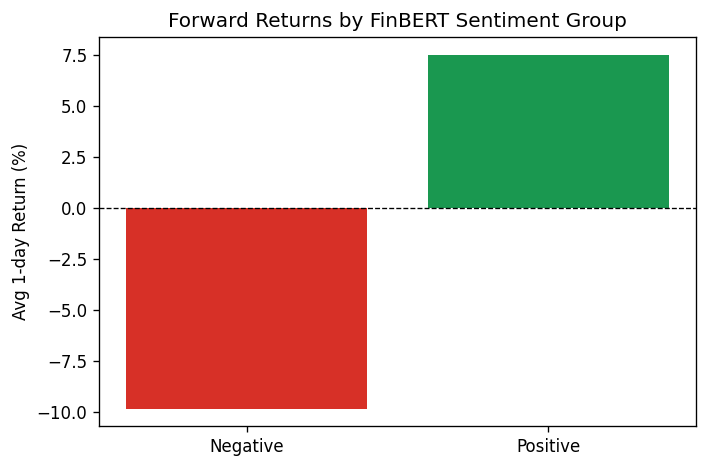


Long-short spread: 17.32%


In [9]:
# With only 10 stocks, use tertiles (3 groups) instead of quintiles
df_clean = df.dropna(subset=['sentiment', 'return_1d']).copy()
df_clean['group'] = df_clean['sentiment'].map(
    lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral')
)

summary = df_clean.groupby('group')['return_1d'].agg(['mean', 'std', 'count'])
summary.columns = ['avg_return', 'std_return', 'n']
summary['avg_return_pct'] = summary['avg_return'] * 100
print(summary.round(4))

import matplotlib.pyplot as plt
colors = {'Negative': '#d73027', 'Neutral': '#fee090', 'Positive': '#1a9850'}
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(summary.index, summary['avg_return_pct'], color=[colors[g] for g in summary.index])
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Avg 1-day Return (%)')
ax.set_title('Forward Returns by FinBERT Sentiment Group')
plt.tight_layout()
plt.savefig('quintile_returns.png', dpi=150)
plt.show()
print(f"\nLong-short spread: {(summary.loc['Positive','avg_return'] - summary.loc['Negative','avg_return'])*100:.2f}%")

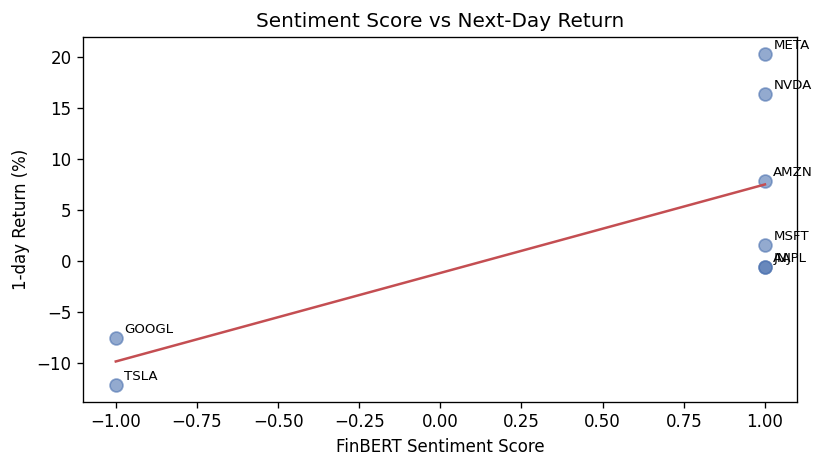

In [10]:
import numpy as np
import matplotlib.pyplot as plt

df_clean = df.dropna(subset=['sentiment', 'return_1d'])
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(df_clean['sentiment'], df_clean['return_1d'] * 100, alpha=0.6, s=60, color='#4C72B0')

m, b = np.polyfit(df_clean['sentiment'], df_clean['return_1d'] * 100, 1)
xs = np.linspace(df_clean['sentiment'].min(), df_clean['sentiment'].max(), 100)
ax.plot(xs, m * xs + b, color='#C44E52', linewidth=1.5)

for _, row in df_clean.iterrows():
    ax.annotate(row['ticker'], (row['sentiment'], row['return_1d'] * 100),
                textcoords="offset points", xytext=(5, 3), fontsize=8)

ax.set_xlabel('FinBERT Sentiment Score')
ax.set_ylabel('1-day Return (%)')
ax.set_title('Sentiment Score vs Next-Day Return')
plt.tight_layout()
plt.savefig('scatter.png', dpi=150)
plt.show()

## 6. Findings & next steps

*(Fill in after running the notebook)*

- **Signal strength:** ...
- **What worked:** ...
- **What didn't:** ...
- **Next steps:** Try longer horizons, larger universe, or sector controls